# OpenBind-HIPPO

- **Target: XX01ZVNS2B**
- **Cycle: 01**

## Prep

- Downloaded XX01ZVNS2B with fragalysis_download.ipynb
- Removed Dengue from metadata.csv: `grep -v -e '^A'`
- Removed Dengue aligned files `rm -r aligned_files/A*`
- Bulkdock setup: `python -m bulkdock setup XX01ZVNS2B`
- Copy aligned files to here: `cp -rv $BULK/TARGETS/XX01ZVNS2B/aligned_files .`

## Imports

In [2]:
%load_ext autoreload
%autoreload 2
import hippo
import mrich
from mrich import print
from pathlib import Path
from os import environ
import shutil
import molparse as mp

# Config

In [3]:
target_name = "XX01ZVNS2B"
target_dir = Path(environ["BULK"]) / "TARGETS" / target_name
cycle_name = "cycle_01"
cycle_dir = Path(cycle_name)
aligned_dir = target_dir / "aligned_files"

## Animal

In [4]:
animal = hippo.HIPPO(target_name, target_dir / f"{target_name}.sqlite")

 Creating HIPPO animal

name = XX01ZVNS2B

db_path = /opt/xchem-fragalysis-2/maxwin/BulkDock/TARGETS/XX01ZVNS2B/XX01ZVNS2B.sqlite

DEBUG: hippo.Database.__init__()

DEBUG: Database.path = /opt/xchem-fragalysis-2/maxwin/BulkDock/TARGETS/XX01ZVNS2B/XX01ZVNS2B.sqlite

DEBUG: hippo.Database.connect()

DEBUG: sqlite3.version='2.6.0'

 Success  Database connected @ /opt/xchem-fragalysis-2/maxwin/BulkDock/TARGETS/XX01ZVNS2B/XX01ZVNS2B.sqlite!

 Success  Initialised animal HIPPO("XX01ZVNS2B")!

## Merging

Run merging algorithms on all poses tagged 'hits'

In [26]:
merge_input_poses = animal.poses(tag="hits")
merge_input_poses

poses tagged "hits": {P × 337}

### Create inputs

- CSV input for Knitwork
- SDF of hits to merge for Knitwork and Fragmenstein
- Protonated PDBs for Knitwork
- Reference PDB for Fragmenstein

In [25]:
# output directories
knitwork_out_dir = cycle_dir / "knitwork"
knitwork_out_dir.mkdir(parents=True, exist_ok=True)
fragmenstein_out_dir = cycle_dir / "fragmenstein"
fragmenstein_out_dir.mkdir(parents=True, exist_ok=True)

In [32]:
# knitwork CSV
knitwork_out_dir = cycle_dir / "knitwork"
knitwork_out_dir.mkdir(parents=True, exist_ok=True)
merge_input_poses.to_knitwork(knitwork_out_dir / f"{cycle_name}_input.csv", path_root=knitwork_out_dir, aligned_files_dir="aligned_files")

out_path = /opt/xchem-fragalysis-2/maxwin/openbind-hippo/xx01zvns2b/cycle_01/knitwork/cycle_01_input.csv

path_root = /opt/xchem-fragalysis-2/maxwin/openbind-hippo/xx01zvns2b/cycle_01/knitwork

aligned_files_dir = aligned_files

 DISK  Writing /opt/xchem-fragalysis-2/maxwin/openbind-hippo/xx01zvns2b/cycle_01/knitwork/cycle_01_input.csv...

In [27]:
# reference apo PDB for Fragmenstein
ref_pose = merge_input_poses[0]
mrich.var("ref_pose", ref_pose)
shutil.copy(ref_pose.apo_path, fragmenstein_out_dir)

ref_pose = C1->P1: "Z0490a"

'cycle_01/fragmenstein/Z0490a_apo-desolv.pdb'

In [30]:
# SDF of hits
out_dir = cycle_dir
out_dir.mkdir(parents=True, exist_ok=True)
merge_input_poses.write_sdf(cycle_dir / f"{cycle_name}_hits.sdf")

Output()

 DISK  Reading /opt/xchem-fragalysis-2/maxwin/BulkDock/TARGETS/XX01ZVNS2B/aligned_files/Z0777a/Z0777a_hippo.pdb...

 Warning  Multiple molecules in SDF P40!

 DISK  Writing cycle_01/cycle_01_hits.sdf...

In [34]:
#protonated PDBs
for pose in mrich.track(merge_input_poses):
    path = pose.apo_path
    sys = mp.parse(path,verbosity=False)
    sys.add_hydrogens(pH=7)
    subdir = Path("aligned_files") / pose.name
    subdir.mkdir(exist_ok=True, parents=True)
    sys.write(subdir / str(path.name).replace('_apo-desolv.pdb', '_apo-desolv-Hs.pdb'), verbosity=1)

Output()

fixer.missingTerminals={<Residue 38 (GLU) of chain 0>: ['OXT'], <Residue 194 (GLU) of chain 1>: ['OXT']}

 DISK  Writing aligned_files/Z0490a/Z0490a_apo-desolv-Hs.pdb...

 Warning  fixer.missingAtoms={<Residue 180 (SER) of chain 1>: [<Atom 3 (OG) of chain 0 residue 0 (SER)>]}!

fixer.missingTerminals={<Residue 37 (VAL) of chain 0>: ['OXT'], <Residue 191 (GLU) of chain 1>: ['OXT']}

...

 DISK  Writing aligned_files/Z5302a/Z5302a_apo-desolv-Hs.pdb...

fixer.missingTerminals={<Residue 38 (GLU) of chain 0>: ['OXT'], <Residue 194 (GLU) of chain 1>: ['OXT']}

 DISK  Writing aligned_files/Z5339a/Z5339a_apo-desolv-Hs.pdb...

fixer.missingTerminals={<Residue 38 (GLU) of chain 0>: ['OXT'], <Residue 194 (GLU) of chain 1>: ['OXT']}

 DISK  Writing aligned_files/Z5348a/Z5348a_apo-desolv-Hs.pdb...

### Run Fragmenstein

```
cd cycle_01/fragmenstein
sbatch --job-name "xx01zvns2b_fragmenstein" --mem 16000 $HOME2/slurm/run_bash_with_conda.sh ../../../run_fragmenstein.sh
```

### Run Knitwork

- [ ] Clone repo on graph-sw-2
- [ ] `cd xx01zvns2b/cycle_01/knitwork`
- [ ] Run the "fragment" step of FragmentKnitwork: `../../../scripts/run_knitwork_fragment.sh`
- [ ] Run the pure "knitting" step of FragmentKnitwork:`../../../scripts/run_knitwork_pure.sh`
- [ ] Run the impure "knitting" step of FragmentKnitwork: `../../../scripts/run_knitwork_impure.sh`
- [ ] Create bulkdock inputs: `knitwork_to_bulkdock.py`

In [4]:
## Fix smiles and aliases

# Fix smiles<>alias

sql = """SELECT pose_id
FROM pose
WHERE pose_smiles GLOB 'C[0-9]*-P[0-9]*';"""

ids = [i for i, in animal.db.execute(sql)]

poses = animal.poses[ids]

print(poses)

if poses:
    
    records = animal.db.select_where(table="pose", query="pose_id", key=f"pose_id IN {poses.str_ids}", multiple=True)
    
    sql = """
    UPDATE pose
    SET pose_alias = NULL, pose_smiles = mol_to_smiles(mol_from_binary_mol(pose_mol))
    WHERE pose_id = ?1
    """
    
    animal.db.executemany(sql, records)

{P × 68120}

In [5]:
animal.db.commit()

## Lauren compound check

In [5]:
animal.compounds(smiles="C[N+]([O-])(O)C1NCCC12CNc1c(F)cc(C(=O)Nc3ccc4c(c3)CNC4)cc12")

C41621 "REUBKMOUYFOYEN-UHFFFAOYSA-N"

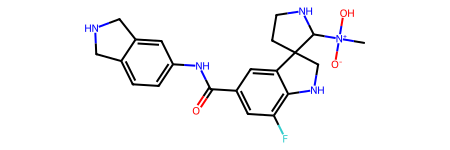

In [9]:
animal.C41621.mol

In [10]:
animal.C41621.get_quotes()

In [12]:
animal.tags.summary()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃ tag                                          ┃ num_compounds ┃ num_poses ┃ num_posed_compounds ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ BAD count                                    │ 0             │ 337       │ 303                 │
│ BulkDock Fragalysis export                   │ 0             │ 5159      │ 4467                │
│ GNINA minimised                              │ 0             │ 3614      │ 3562                │
│ GOOD count                                   │ 0             │ 337       │ 303                 │
│ MEDIOCRE count                               │ 0             │ 337       │ 303                 │
│ Main status                                  │ 0             │ 337       │ 303                 │
│ [Other] S1                                   │ 0             │ 45        │ 43                  │
│ [Other] S2                                   │ 0             │ 4         │ 3                   │
│ [Other] upload_1 2025-02-11                  │ 0             │ 253       │ 231                 │
│ [Other] upload_2 2025-02-21                  │ 0             │ 5         │ 5                   │
│ [Other] upload_3 2025-02-26                  │ 0             │ 13        │ 13                  │
│ [Other] upload_4 2025-03-05                  │ 0             │ 7         │ 7                   │
│ [Other] upload_5 2025-03-11                  │ 0             │ 18        │ 18                  │
│ [Other] upload_6 2025-04-15                  │ 0             │ 37        │ 34                  │
│ [Other] upload_7 2025-04-29                  │ 0             │ 4         │ 4                   │
│ fragmenstein_placed                          │ 0             │ 83861     │ 63391               │
│ hits                                         │ 303           │ 337       │ 303                 │
│ openbind_xx01zvns2b_c1_elaborated_scaffolds  │ 64            │ 0         │ 0                   │
│ openbind_xx01zvns2b_c1_elabs                 │ 4731          │ 0         │ 0                   │
│ openbind_xx01zvns2b_c1_fragmenstein          │ 24878         │ 30591     │ 24874               │
│ openbind_xx01zvns2b_c1_knitwork_impure       │ 15314         │ 15718     │ 13161               │
│ openbind_xx01zvns2b_c1_knitwork_pure         │ 17721         │ 21811     │ 17714               │
│ openbind_xx01zvns2b_c1_scaffolds             │ 3614          │ 3614      │ 3563                │
│ openbind_xx01zvns2b_c1_scaffolds_chemok      │ 767           │ 0         │ 0                   │
│ openbind_xx01zvns2b_c1_scaffolds_chemok_bbok │ 459           │ 459       │ 459                 │
│ soaks                                        │ 3613          │ 0         │ 0                   │
│ xx01zvns2b_c1_elab_bulkdock_input            │ 7898          │ 15741     │ 7898                │
└──────────────────────────────────────────────┴───────────────┴───────────┴─────────────────────┘

In [13]:
animal.compounds(tag="openbind_xx01zvns2b_c1_elabs").poses.

{P × 15879}

In [14]:
filtered_elab_poses = animal.compounds(tag="openbind_xx01zvns2b_c1_elabs").poses.filter(key="distance_score", value="2.0", operator="<=").filter(key="energy_score", value="0.0", operator="<=")
# filtered_elab_poses.add_tag("openbind_a71ev2a_c1_elabs_filtered")
# filtered_posed_elabs = filtered_elab_poses.compounds
# filtered_posed_elabs.add_tag("openbind_a71ev2a_c1_elabs_filtered")
# chemspace_filtered = filtered_posed_elabs + posed_elabs.scaffolds
# chemspace_filtered
filtered_elab_poses.compounds

{C × 4731}